In [1]:
from visualisation import *

In [2]:
def get_max_P(V, Srated=1, v1=253, v2=260):
    if V < v1:
        return Srated
    elif V > v2:
        return .2 * Srated
    else:
        m = (Srated - .2*Srated) / (v1 - v2)
        P = m * (V - v2) + .2*Srated
        return P
    
def get_voltvar_Q(V, P, Srated=1, v1=207, v2=220, v3=240, v4=258, Q1=.44, Q4=.60):
    if np.abs(P) < .2 * Srated:
        return 0
    if V <= v1:
        Q = Q1* Srated
    elif v1 <= V < v2:
        m = (Q1* Srated - 0) / (v1 - v2)
        Q = m * (V - v2)
    elif v2 <= V <= v3:
        Q = 0
    elif v3 < V < v4:
        m = (0 - Q4* Srated) / (v3 - v4)
        Q = -m * (V - v4) - Q4* Srated
    else:  # V >= v4
        Q = - Q4* Srated
    return Q

def Q_capability(P, Srated=1):
    if P < .2 * Srated:
        Q = 0
    elif P <= .6 * Srated:
        Q = 0.44 * Srated
    elif P <= .8 * Srated:
        S_pf = P / 0.8
        Q = np.sqrt(S_pf**2 - P**2)
    else:
        Q = np.sqrt(Srated**2 - P**2)
    return Q

In [9]:
S_rated = 100
V_vec = np.arange(240, 253.01, .01)
V_vec = np.round(V_vec, 2)
df = pd.DataFrame(V_vec, columns=['V'])
df['P_only'] = df['V'].apply(lambda x: get_max_P(x, Srated=S_rated))
df['Q_only'] = df.apply(lambda row: get_voltvar_Q(row['V'], 20, Srated=S_rated), axis=1)
df['max_P_with_Q_only'] = (S_rated**2 - df['Q_only']**2)**0.5
df['max_P_with_Q_nd_P'] = df.apply(lambda row: np.minimum(row['P_only'], row['max_P_with_Q_only']), axis=1)
df['absorb_Q'] = df.apply(lambda row: Q_capability(row['max_P_with_Q_nd_P'], Srated=S_rated), axis=1)
df['supply_Q'] = - df['absorb_Q']
df['S_absorbing'] = (df['absorb_Q']**2 + df['max_P_with_Q_nd_P']**2)**0.5


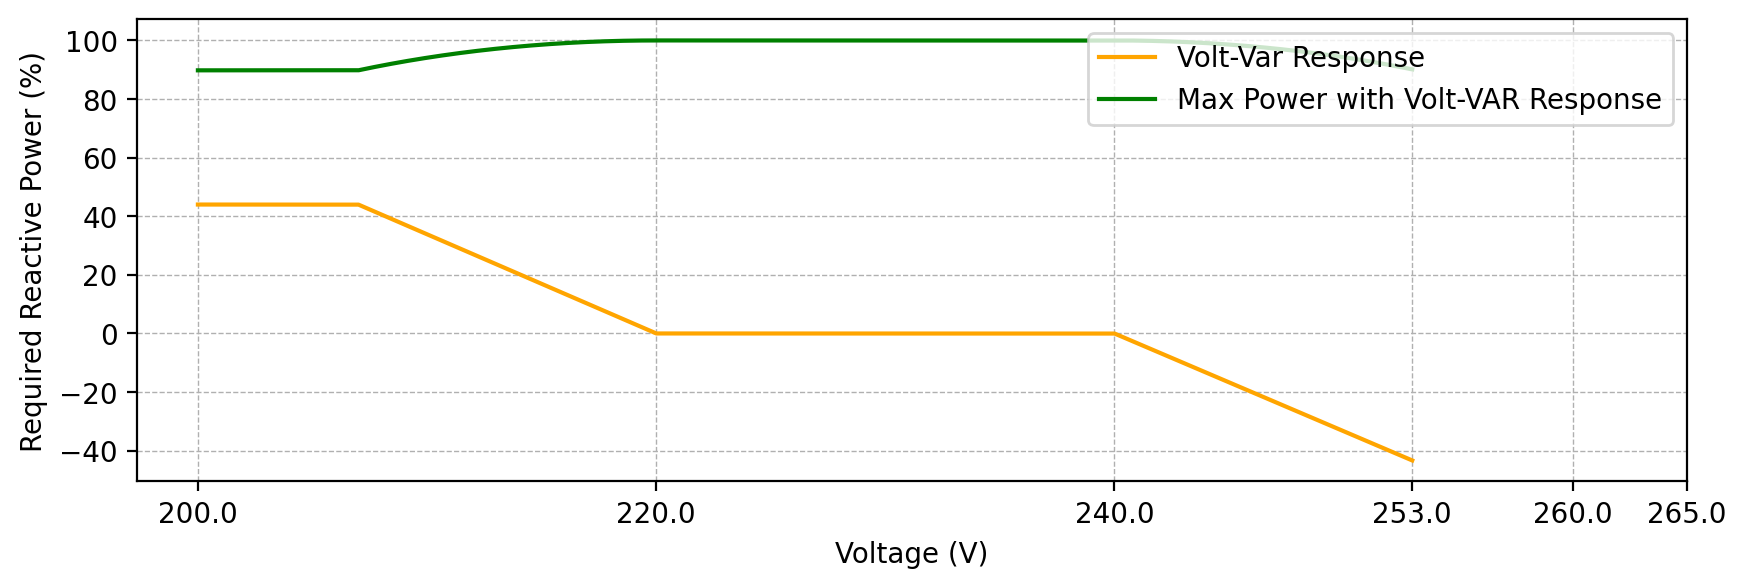

In [8]:
fig = plt.figure(figsize=(10, 3), dpi=200)
ax = fig.add_subplot(111)
ax.plot(df['V'], df['Q_only'], label='Volt-Var Response ', color='orange')
ax.plot(df['V'], df['max_P_with_Q_only'], label='Max Power with Volt-VAR Response', color='green')
# ax.plot(df['V'], df['max_P_with_Q_nd_P'], label='Max Power with Volt-VAR and Volt-Watt Response', linestyle='dotted', linewidth=4, color='red')
# ax2.plot(df['V'], df['absorb_Q'], label='Absorbing Q limit', color='yellow')
# ax2.plot(df['V'], df['supply_Q'], label='Supplying Q limit', color='purple')

ax.set_xlabel('Voltage (V)')
# ax.set_ylabel('Max Power (%)')
ax.set_ylabel('Required Reactive Power (%)')
# ax.set_xticks([min(V_vec), max(V_vec), 253, 254, 254.75, 255, 255.6, 256, 258, 260, 265])
ax.set_xticks([min(V_vec), max(V_vec), 220, 240, 260, 265])
ax.set_xticklabels([f'{x}' for x in ax.get_xticks()], rotation=0)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(loc='upper right')
# ax.set_ylim(0, 105)
# ax2.legend(loc='center left')

In [3]:
S_rated = 100
V_vec = np.arange(240, 262.01, .01)
V_vec = np.round(V_vec, 2)
df = pd.DataFrame(V_vec, columns=['V'])
df['P_only'] = df['V'].apply(lambda x: get_max_P(x, Srated=S_rated))
df['Q_only'] = df.apply(lambda row: get_voltvar_Q(row['V'], 20, Srated=S_rated), axis=1)
df['max_P_with_Q_only'] = (S_rated**2 - df['Q_only']**2)**0.5
df['max_P_with_Q_nd_P'] = df.apply(lambda row: np.minimum(row['P_only'], row['max_P_with_Q_only']), axis=1)
df['absorb_Q'] = df.apply(lambda row: Q_capability(row['max_P_with_Q_nd_P'], Srated=S_rated), axis=1)
df['supply_Q'] = - df['absorb_Q']
df['S_absorbing'] = (df['absorb_Q']**2 + df['max_P_with_Q_nd_P']**2)**0.5


In [23]:
df.query("V == 255")

,V,P_only,Q_only,max_P_with_Q_only,max_P_with_Q_nd_P,absorb_Q,supply_Q,S_absorbing
500,255.0,77.142857,-50.0,86.60254,77.142857,57.857143,-57.857143,96.428571


In [14]:
font = {'weight': 'normal',
        'size' : 9}
matplotlib.rc('font', **font)

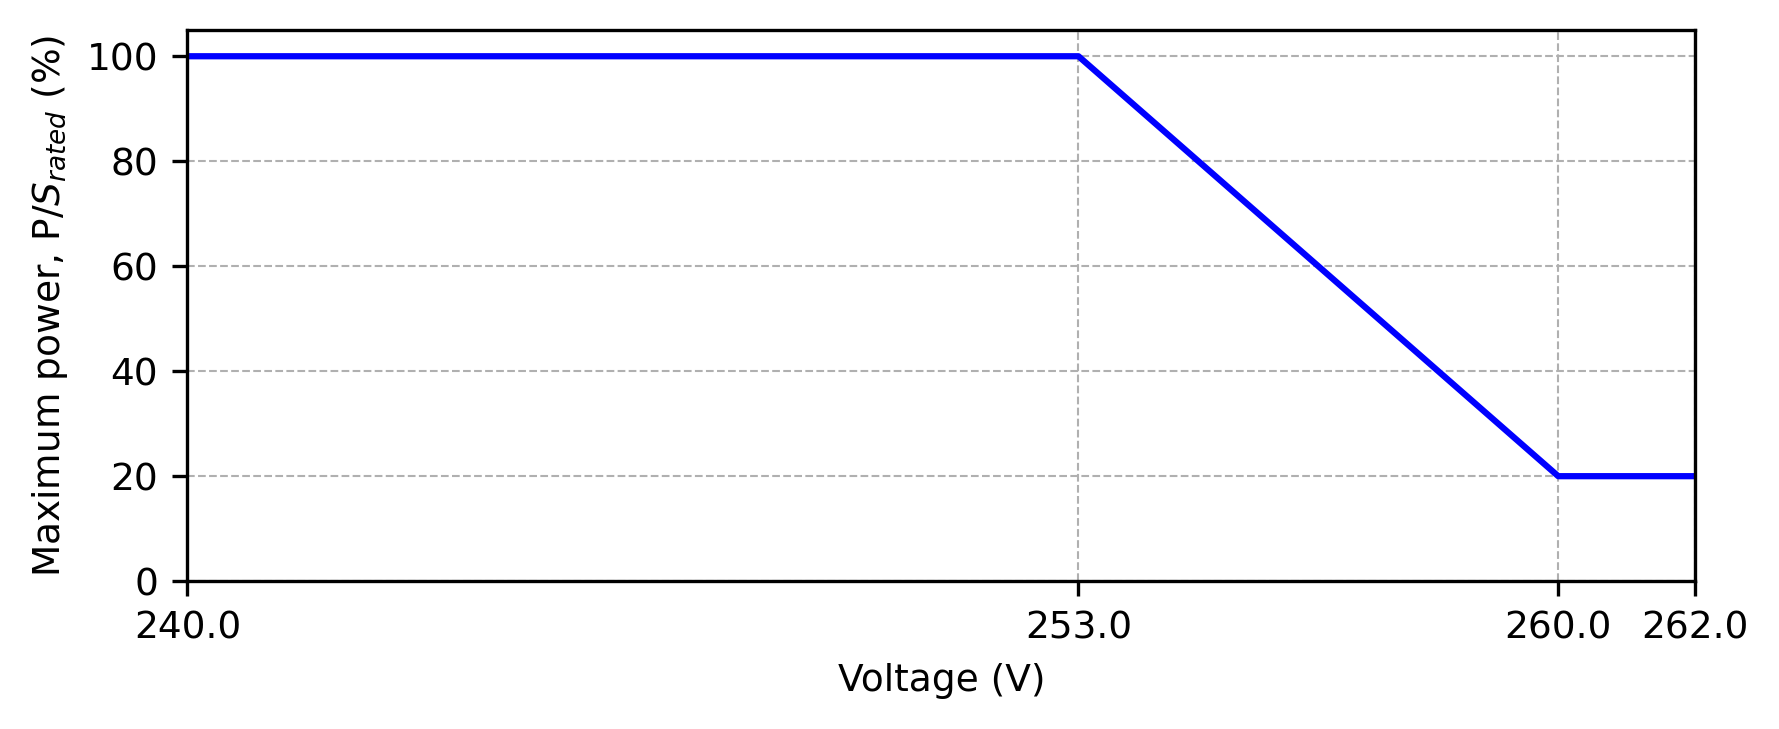

In [17]:
fig = plt.figure(figsize=(6, 2.5), dpi=300)
ax = fig.add_subplot(111)
ax.plot(df['V'], df['P_only'], label='Volt-Watt Response ', color='blue')
ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Maximum power, P/$S_{rated}$ (%)')
ax.set_xticks([min(V_vec), max(V_vec), 253, 260, 265])
ax.set_xticklabels([f'{x}' for x in ax.get_xticks()], rotation=0)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
# ax.legend(loc='center left')
ax.set_ylim(0, 105)
ax.margins(x=0)
plt.tight_layout()
plt.savefig('Figures/volt_watt_response.png', dpi=300, bbox_inches='tight')
# plt.show()

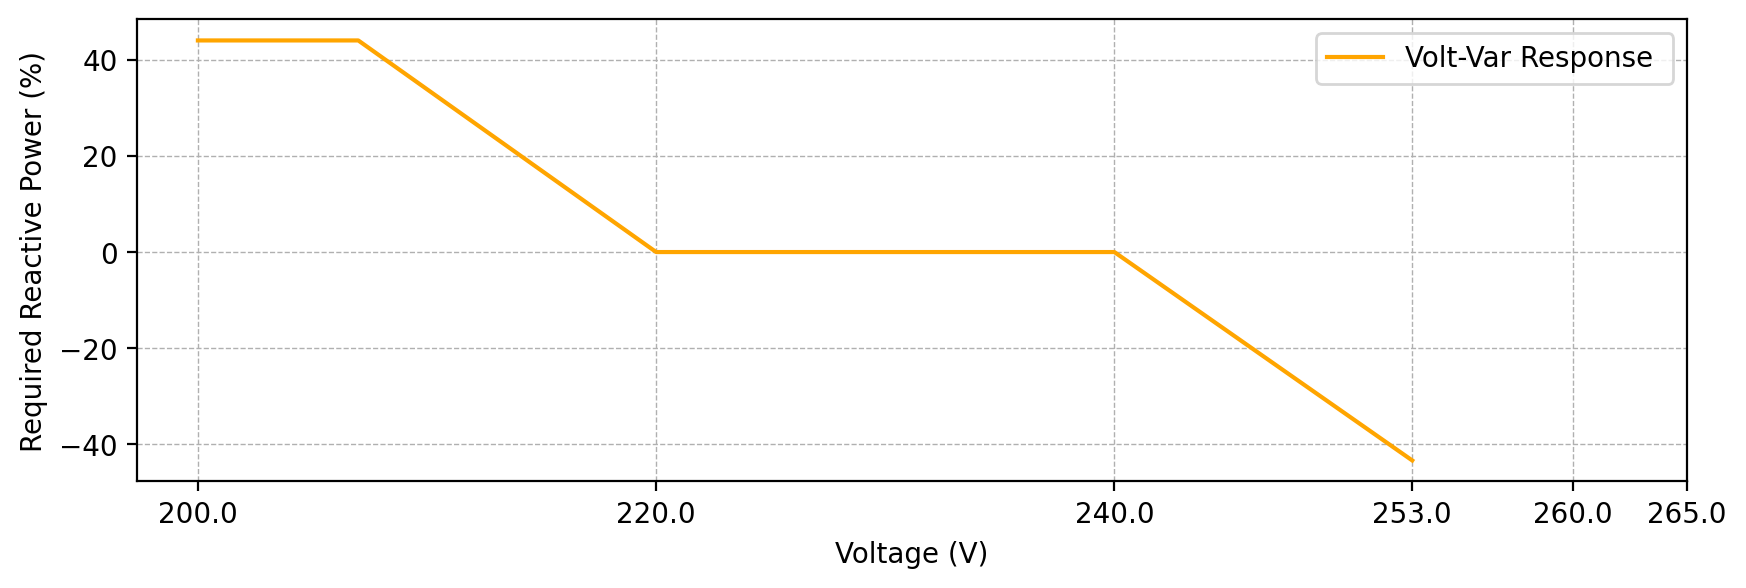

In [7]:
fig = plt.figure(figsize=(10, 3), dpi=200)
ax = fig.add_subplot(111)
ax.plot(df['V'], df['Q_only'], label='Volt-Var Response ', color='orange')
# ax.plot(df['V'], df['max_P_with_Q_only'], label='Max Power with Volt-VAR Response', color='green')
# ax.plot(df['V'], df['max_P_with_Q_nd_P'], label='Max Power with Volt-VAR and Volt-Watt Response', linestyle='dotted', linewidth=4, color='red')
# ax2.plot(df['V'], df['absorb_Q'], label='Absorbing Q limit', color='yellow')
# ax2.plot(df['V'], df['supply_Q'], label='Supplying Q limit', color='purple')

ax.set_xlabel('Voltage (V)')
# ax.set_ylabel('Max Power (%)')
ax.set_ylabel('Required Reactive Power (%)')
# ax.set_xticks([min(V_vec), max(V_vec), 253, 254, 254.75, 255, 255.6, 256, 258, 260, 265])
ax.set_xticks([min(V_vec), max(V_vec), 220, 240, 260, 265])
ax.set_xticklabels([f'{x}' for x in ax.get_xticks()], rotation=0)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(loc='upper right')
# ax.set_ylim(0, 105)
# ax2.legend(loc='center left')

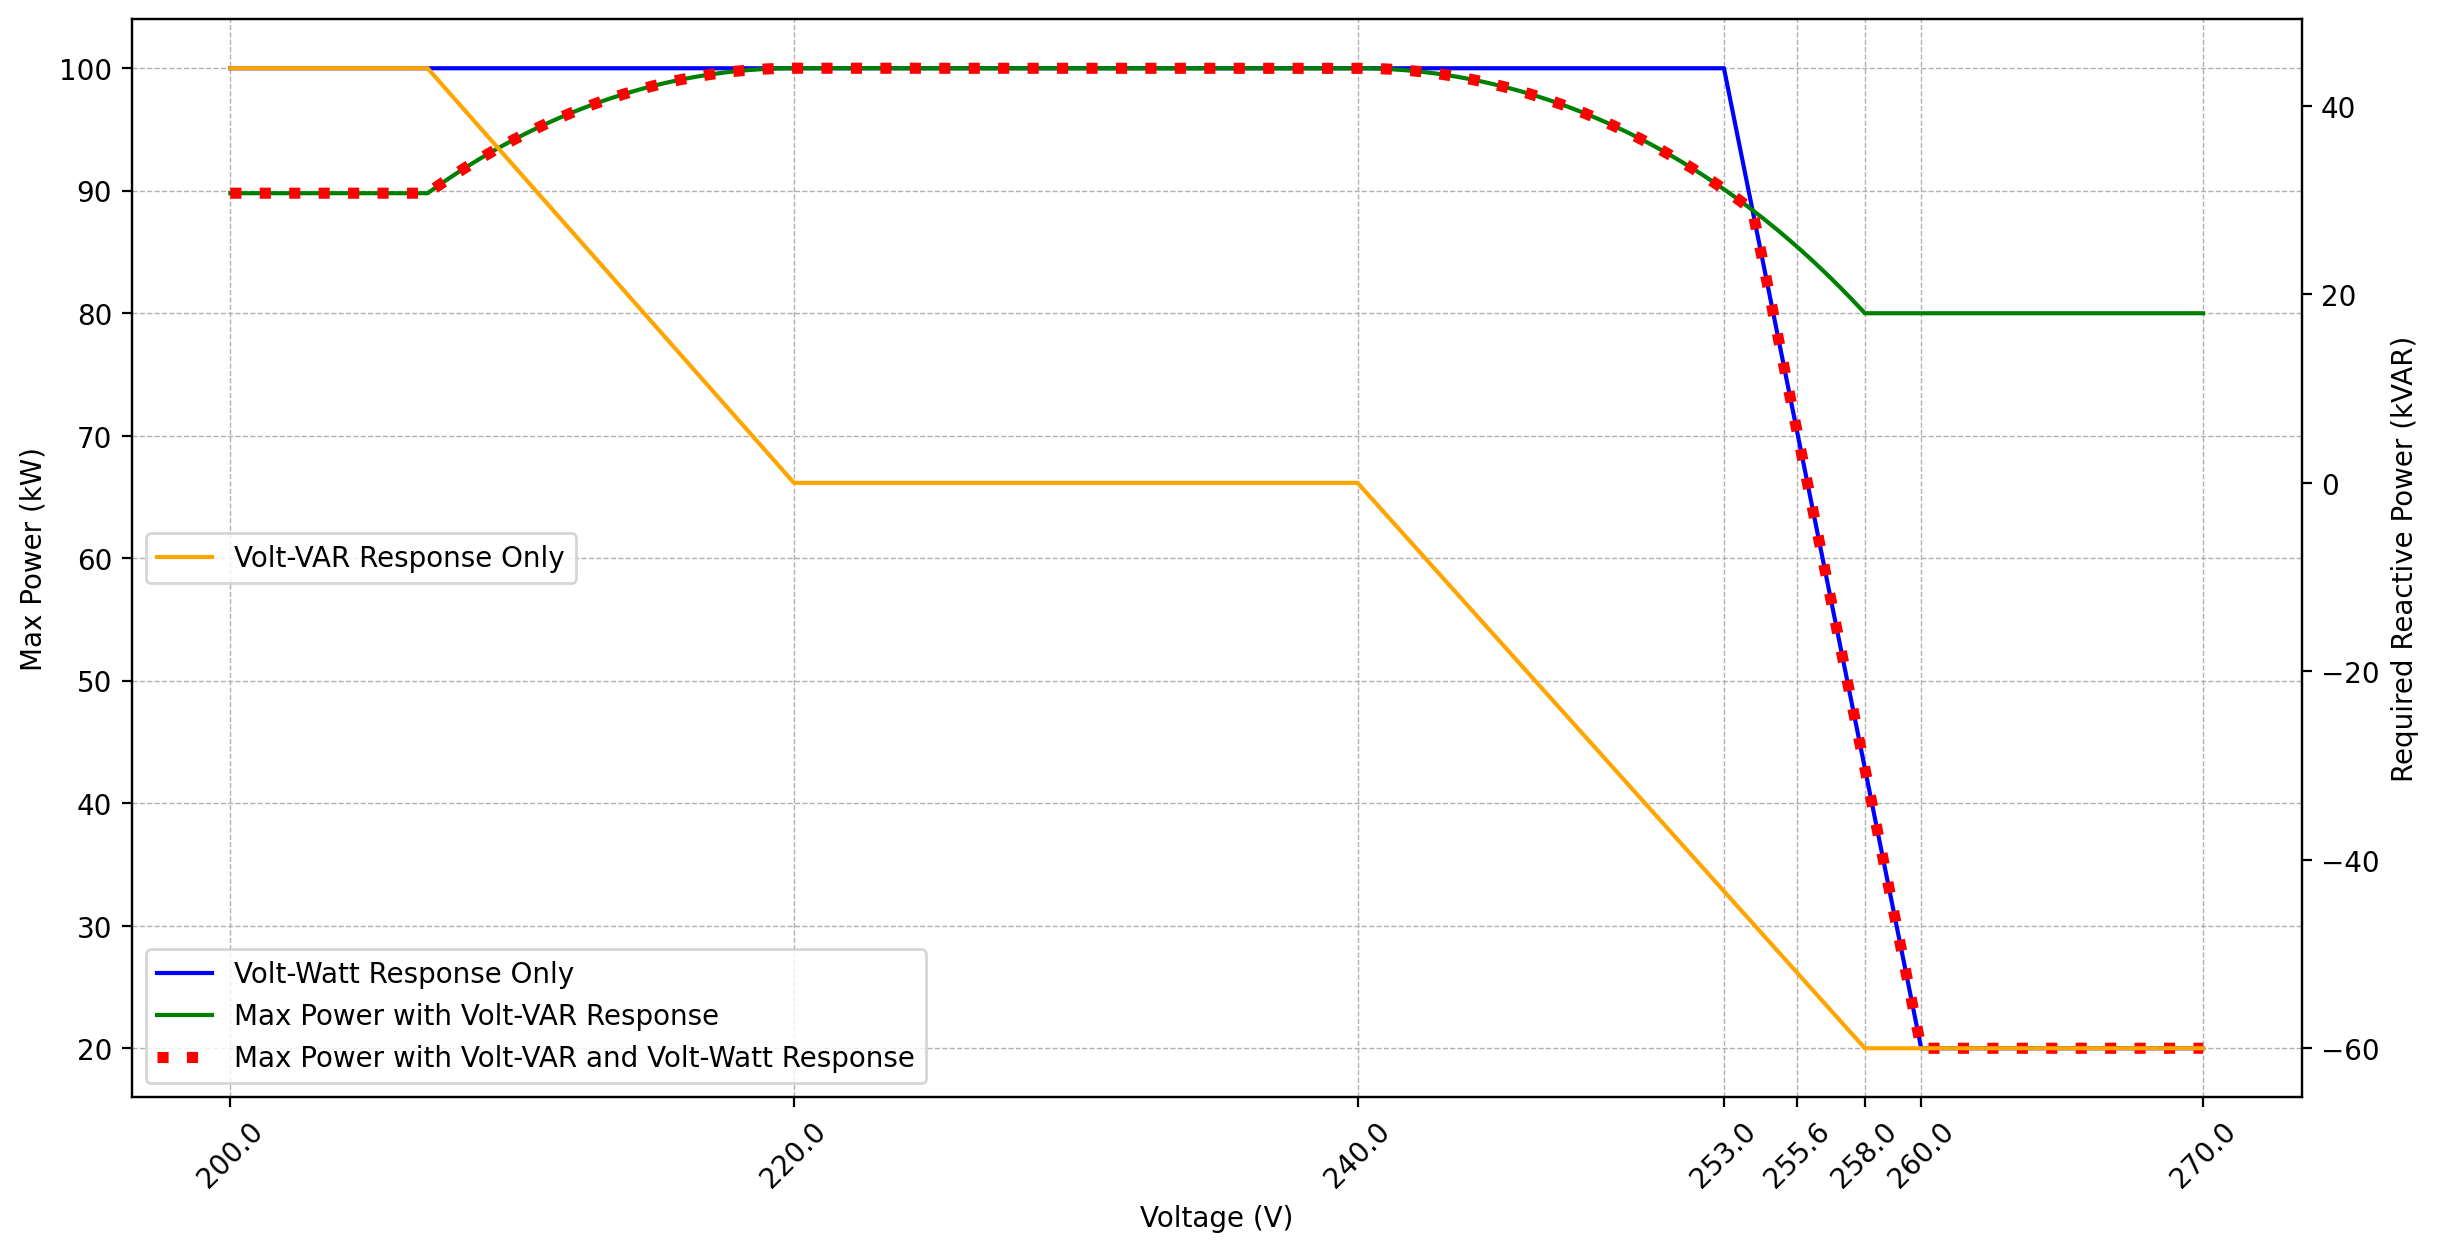

In [13]:
fig = plt.figure(figsize=(14, 7), dpi=200)
ax = fig.add_subplot(111)
ax2 = ax.twinx()
ax.plot(df['V'], df['P_only'], label='Volt-Watt Response Only', color='blue')
ax2.plot(df['V'], df['Q_only'], label='Volt-VAR Response Only', color='orange')
ax.plot(df['V'], df['max_P_with_Q_only'], label='Max Power with Volt-VAR Response', color='green')
ax.plot(df['V'], df['max_P_with_Q_nd_P'], label='Max Power with Volt-VAR and Volt-Watt Response', linestyle='dotted', linewidth=4, color='red')
# ax2.plot(df['V'], df['absorb_Q'], label='Absorbing Q limit', color='yellow')
# ax2.plot(df['V'], df['supply_Q'], label='Supplying Q limit', color='purple')

ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Max Power (kW)')
ax2.set_ylabel('Required Reactive Power (kVAR)')
ax.set_xticks([min(V_vec), max(V_vec), 220, 240, 253, 255.6, 258, 260])
ax.set_xticklabels([f'{x}' for x in ax.get_xticks()], rotation=45)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(loc='lower left')
ax2.legend(loc='center left')

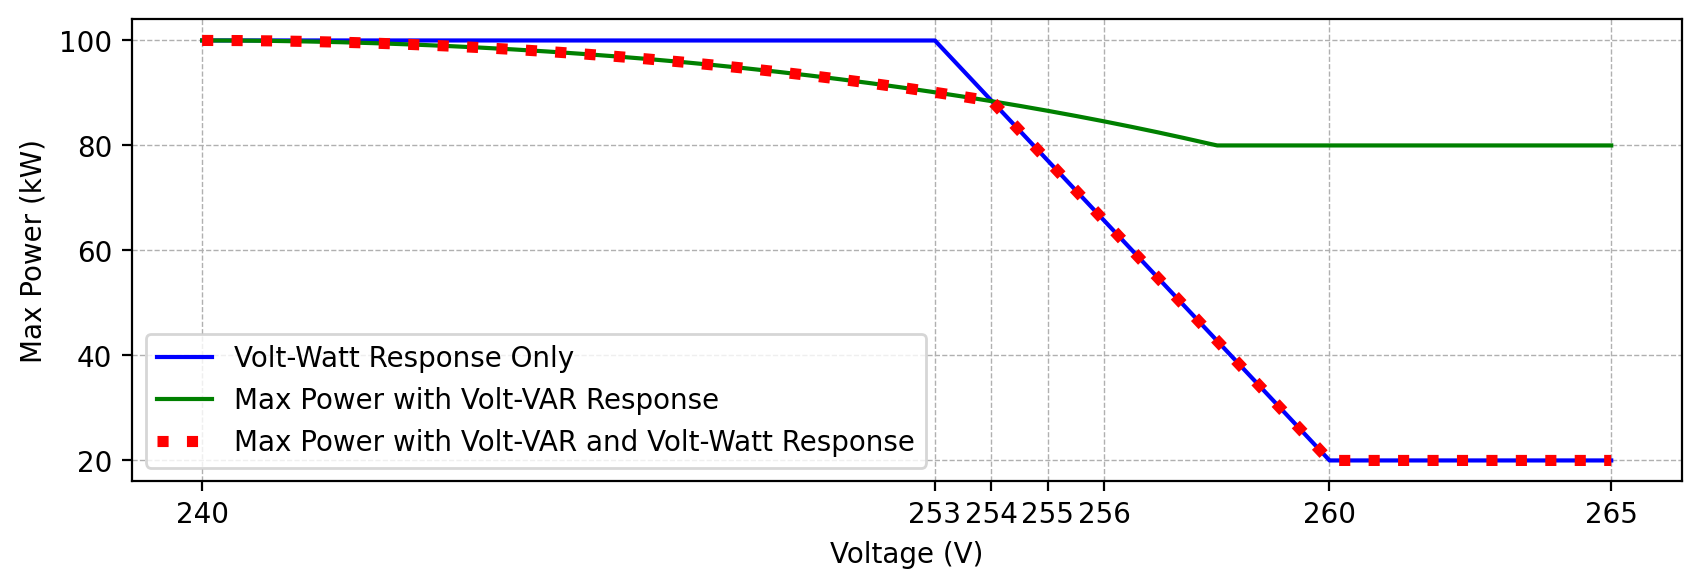

In [7]:
S_rated = 100
V_vec = np.arange(240, 265, .001)
df = pd.DataFrame(V_vec, columns=['V'])
df['P_only'] = df['V'].apply(lambda x: get_max_P(x, Srated=S_rated))
df['Q_only'] = df.apply(lambda row: get_voltvar_Q(row['V'], 20, Srated=S_rated), axis=1)
df['max_P_with_Q_only'] = (S_rated**2 - df['Q_only']**2)**0.5
df['max_P_with_Q_nd_P'] = df.apply(lambda row: np.minimum(row['P_only'], row['max_P_with_Q_only']), axis=1)
fig = plt.figure(figsize=(10, 3), dpi=200)
ax = fig.add_subplot(111)
# ax2 = ax.twinx()
ax.plot(df['V'], df['P_only'], label='Volt-Watt Response Only', color='blue')
ax2.plot(df['V'], df['Q_only'], label='Volt-VAR Response Only', color='orange')
ax.plot(df['V'], df['max_P_with_Q_only'], label='Max Power with Volt-VAR Response', color='green')
ax.plot(df['V'], df['max_P_with_Q_nd_P'], label='Max Power with Volt-VAR and Volt-Watt Response', linestyle='dotted', linewidth=4, color='red')
ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Max Power (kW)')
# ax2.set_ylabel('Required Reactive Power (kVAR)')
ax.set_xticks([min(V_vec), max(V_vec),253, 254, 255, 256, 260])
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(loc='lower left')
ax2.legend(loc='center left')